# AI231 — Milestone 1: 3-Layer CNN for MNIST (Tensor Operations Only)

**Goal.** Build a 3-layer convolutional neural network for MNIST digit classification
using **only low-level tensor operations** (PyTorch tensors, `torch.nn.Parameter`,
`einops`, and `einsum`). We deliberately do **not** use any high-level module such as
`nn.Conv2d`, `nn.Linear`, `nn.MaxPool2d`, or `nn.AvgPool2d` — every convolution,
pooling, and fully-connected step is implemented by hand so the underlying tensor
math is visible.

**Architecture** (input is a `1 x 28 x 28` grayscale image):

| # | Operation | Tensor shape (per image) |
|---|-----------|--------------------------|
|   | Input | `1 x 28 x 28` |
| 1 | Conv1 (1->16, k=3, p=1) + ReLU + MaxPool2 | `16 x 14 x 14` |
| 2 | Conv2 (16->32, k=3, p=1) + ReLU + MaxPool2 | `32 x 7 x 7` |
| 3 | Conv3 (32->64, k=3, p=1) + ReLU + GlobalAvgPool | `64 x 1 x 1` |
|   | Flatten | `64` |
|   | Linear (64->10) | `10` (logits) |

**Training setup.** MNIST, 5 epochs, batch size 128, Adam (lr=1e-3),
cross-entropy loss. Random seeds are fixed for reproducibility.


In [1]:
# ============================================================
# Imports & reproducibility
# ============================================================
import torch
import torch.nn.functional as F          # only for activations/loss (NOT conv/linear/pool modules)
from einops import rearrange, reduce
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# --- Fix every RNG so the run is fully reproducible ---
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, '| torch:', torch.__version__)


Device: cpu | torch: 2.13.0+cpu


In [2]:
# ============================================================
# Dataset loading & preprocessing
# ============================================================
# torchvision.datasets.MNIST downloads the standard MNIST set.
# We convert to float tensors in [0, 1] and stack into (N, 1, 28, 28).
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.ToTensor(),                 # uint8 (28,28) -> float (1,28,28) in [0,1]
])

train_ds = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Stack into a single tensor for fast, deterministic mini-batching.
# X: (N, 1, 28, 28)   y: (N,)  (labels are long ints 0..9)
X_train = torch.stack([train_ds[i][0] for i in range(len(train_ds))])   # (60000, 1, 28, 28)
y_train = torch.tensor([train_ds[i][1] for i in range(len(train_ds))], dtype=torch.long)  # (60000,)
X_test  = torch.stack([test_ds[i][0]  for i in range(len(test_ds))])    # (10000, 1, 28, 28)
y_test  = torch.tensor([test_ds[i][1]  for i in range(len(test_ds))], dtype=torch.long)   # (10000,)

print('Train:', tuple(X_train.shape), tuple(y_train.shape))
print('Test :', tuple(X_test.shape),  tuple(y_test.shape))
print('Label range:', int(y_train.min()), '-', int(y_train.max()))


Train: (60000, 1, 28, 28) (60000,)
Test : (10000, 1, 28, 28) (10000,)
Label range: 0 - 9


In [3]:
# ============================================================
# Model: 3-layer CNN built purely from tensor operations
# ============================================================
# We subclass nn.Module ONLY to hold parameters and define forward().
# Inside forward() there are NO nn.Conv2d / nn.Linear / nn.MaxPool2d /
# nn.AvgPool2d calls — each op is written out with einops/einsum.
import torch.nn as nn

class TensorCNN(nn.Module):
    def __init__(self, in_ch=1, c1=16, c2=32, c3=64, num_classes=10):
        super().__init__()
        # ---- Convolution weights & biases (learnable Parameters) ----
        # Weight layout: (out_ch, in_ch, kH, kW). We use square 3x3 kernels.
        # He (Kaiming) init: std = sqrt(2 / fan_in), fan_in = in_ch * k * k.
        def conv_params(out_ch, in_ch, k=3):
            std = (2.0 / (in_ch * k * k)) ** 0.5
            w = torch.empty(out_ch, in_ch, k, k)
            nn.init.uniform_(w, -std, std)          # uniform Kaiming
            b = torch.zeros(out_ch)
            return nn.Parameter(w), nn.Parameter(b)

        self.w1, self.b1 = conv_params(c1, in_ch)   # (16, 1, 3, 3), (16,)
        self.w2, self.b2 = conv_params(c2, c1)      # (32,16, 3, 3), (32,)
        self.w3, self.b3 = conv_params(c3, c2)      # (64,32, 3, 3), (64,)

        # ---- Fully-connected layer (manual matmul) ----
        # Input feature dim after global-average-pool of conv3 = c3 = 64.
        # Weights: (num_classes, in_features) so that logits = x @ W^T + b.
        std = (2.0 / c3) ** 0.5
        self.fw = nn.Parameter(torch.empty(num_classes, c3).uniform_(-std, std))  # (10, 64)
        self.fb = nn.Parameter(torch.zeros(num_classes))                          # (10,)

    # ------------------------------------------------------------------
    # Helper: manual 2-D convolution (stride 1, SAME padding) via einops+einsum
    #   x : (B, Cin, H, W)
    #   w : (Cout, Cin, k, k)
    #   b : (Cout,)
    #   out: (B, Cout, H, W)   (same spatial size thanks to padding)
    # ------------------------------------------------------------------
    @staticmethod
    def conv2d_same(x, w, b, k=3):
        B, Cin, H, W = x.shape
        Cout = w.shape[0]
        pad = k // 2

        # 1) Zero-pad the borders so the output spatial size equals the input.
        #    (B, Cin, H, W) -> (B, Cin, H+2p, W+2p)
        x = F.pad(x, (pad, pad, pad, pad))

        # 2) Extract every k x k receptive-field patch (im2col style).
        #    .unfold(dim, size, step) slides a window and returns a view.
        #    Two unfolds give all (k x k) patches:
        #    (B, Cin, H, W) -> (B, Cin, H, W, k, k)
        patches = x.unfold(2, k, 1).unfold(3, k, 1).contiguous()

        # 3) Reorder axes with einops so batch/spatial lead and the
        #    channel + kernel axes trail:
        #    (B, Cin, H, W, k, k) -> (B, H, W, Cin, k, k)
        patches = rearrange(patches, 'b c h w i j -> b h w c i j')

        # 4) Contract every patch against its filter with einsum.
        #    (torch.einsum: the pattern comes LAST.)
        #    For each output channel o, sum over (cin, kh, kw):
        #    out[b,o,h,w] = sum_{cin,kh,kw} patches[b,h,w,cin,kh,kw] * w[o,cin,kh,kw]
        out = torch.einsum('b h w c i j, o c i j -> b o h w', patches, w)

        # 5) Add the per-output-channel bias: (B, Cout, H, W) + (Cout,)
        out = out + b.view(1, Cout, 1, 1)
        return out

    # ------------------------------------------------------------------
    # Helper: manual 2x2 max pooling (stride 2). No nn.MaxPool2d.
    #   x : (B, C, H, W) with H,W even -> (B, C, H/2, W/2)
    # ------------------------------------------------------------------
    @staticmethod
    def maxpool2(x, k=2):
        # Reshape each HxW map into (H/k, k, W/k, k) blocks, then take the max
        # over the two inner (k, k) axes.
        # (B, C, H, W) -> (B, C, H/k, k, W/k, k) -> max over axes 3,5 -> (B, C, H/k, W/k)
        B, C, H, W = x.shape
        x = rearrange(x, 'b c (h q) (w r) -> b c h w q r', q=k, r=k)
        x = x.max(dim=-1).values.max(dim=-1).values
        return x

    # ------------------------------------------------------------------
    # Helper: manual global average pooling. No nn.AvgPool2d.
    #   x : (B, C, H, W) -> (B, C, 1, 1)  (mean over H and W)
    # ------------------------------------------------------------------
    @staticmethod
    def global_avg_pool(x):
        # Average over the two spatial dims, keeping the channel dim.
        # (B, C, H, W) -> (B, C, 1, 1)
        return reduce(x, 'b c h w -> b c 1 1', 'mean')

    def forward(self, x):
        # x : (B, 1, 28, 28)

        # ---- Block 1: Conv1 -> ReLU -> MaxPool2 ----
        x = self.conv2d_same(x, self.w1, self.b1, k=3)   # (B, 16, 28, 28)
        x = torch.relu(x)                                 # (B, 16, 28, 28)
        x = self.maxpool2(x, k=2)                         # (B, 16, 14, 14)

        # ---- Block 2: Conv2 -> ReLU -> MaxPool2 ----
        x = self.conv2d_same(x, self.w2, self.b2, k=3)   # (B, 32, 14, 14)
        x = torch.relu(x)                                 # (B, 32, 14, 14)
        x = self.maxpool2(x, k=2)                         # (B, 32, 7, 7)

        # ---- Block 3: Conv3 -> ReLU -> GlobalAvgPool ----
        x = self.conv2d_same(x, self.w3, self.b3, k=3)   # (B, 64, 7, 7)
        x = torch.relu(x)                                 # (B, 64, 7, 7)
        x = self.global_avg_pool(x)                       # (B, 64, 1, 1)

        # ---- Flatten: (B, 64, 1, 1) -> (B, 64) ----
        x = rearrange(x, 'b c h w -> b (c h w)')          # (B, 64)

        # ---- Manual fully-connected layer: logits = x @ W^T + b ----
        # fw: (10, 64). x @ fw^T : (B, 64) @ (64, 10) -> (B, 10)
        logits = torch.einsum('b i, o i -> b o', x, self.fw) + self.fb
        return logits                                     # (B, 10)


model = TensorCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'Model created on {device}. Total learnable parameters: {n_params:,}')
print('Parameters:')
for name, p in model.named_parameters():
    print(f'  {name:6s} {tuple(p.shape)}')


Model created on cpu. Total learnable parameters: 23,946
Parameters:
  w1     (16, 1, 3, 3)
  b1     (16,)
  w2     (32, 16, 3, 3)
  b2     (32,)
  w3     (64, 32, 3, 3)
  b3     (64,)
  fw     (10, 64)
  fb     (10,)


In [4]:
# ============================================================
# Loss & optimizer
# ============================================================
# ---- Cross-entropy loss, implemented with raw tensor ops (no nn module) ----
# L = -1/B * sum_b log( softmax(z_b)[y_b] )
# Numerically stable form: subtract row max before exp (prevents overflow).

def cross_entropy(logits, targets):
    """Manual cross-entropy. logits: (B, C), targets: (B,) int64. Returns scalar."""
    # (B, C) -> subtract per-row max for stability, then log-sum-exp
    z_max = logits.max(dim=1, keepdim=True).values          # (B, 1)
    log_probs = logits - z_max - torch.logsumexp(logits - z_max, dim=1, keepdim=True)
    # Gather the log-probability of the true class for each example: (B, C) -> (B,)
    nll = -log_probs[torch.arange(logits.size(0)), targets]  # (B,)
    return nll.mean()                                       # scalar
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

BATCH_SIZE = 128
train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
print(f'Optimizer: Adam(lr=1e-3) | Batch size: {BATCH_SIZE} | '
      f'Steps/epoch: {len(train_loader)}')


Optimizer: Adam(lr=1e-3) | Batch size: 128 | Steps/epoch: 469


In [5]:
# ============================================================
# Training loop (exactly 5 epochs) with per-epoch logging
# ============================================================
NUM_EPOCHS = 5
model.train()
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)      # (B,1,28,28), (B,)

        optimizer.zero_grad()
        logits = model(xb)                          # (B, 10)
        loss = cross_entropy(logits, yb)            # scalar (manual, tensor-ops only)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)                # (B,)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    history.append((epoch, epoch_loss, epoch_acc))
    print(f'Epoch {epoch}/{NUM_EPOCHS} | train loss: {epoch_loss:.4f} | '
          f'train acc: {epoch_acc:.4f}')

print('\nTraining complete.')


Epoch 1/5 | train loss: 0.9734 | train acc: 0.6945


Epoch 2/5 | train loss: 0.3125 | train acc: 0.9085


Epoch 3/5 | train loss: 0.2306 | train acc: 0.9309


Epoch 4/5 | train loss: 0.1933 | train acc: 0.9427


Epoch 5/5 | train loss: 0.1669 | train acc: 0.9497

Training complete.


In [6]:
# ============================================================
# Evaluation on the MNIST test split
# ============================================================
model.eval()
with torch.no_grad():
    # Evaluate in batches to avoid a huge (10000, ...) intermediate on CPU.
    all_preds = []
    for i in range(0, len(X_test), 512):
        xb = X_test[i:i+512].to(device)             # (n, 1, 28, 28)
        logits = model(xb)                          # (n, 10)
        all_preds.append(logits.argmax(dim=1).cpu())
    preds = torch.cat(all_preds)                    # (10000,)

test_correct = (preds == y_test).sum().item()
test_acc = test_correct / len(y_test)
print(f'\n===== TEST RESULT =====')
print(f'Test samples : {len(y_test)}')
print(f'Correct      : {test_correct}')
print(f'TEST ACCURACY: {test_acc:.4f}  ({test_acc*100:.2f}%)')



===== TEST RESULT =====
Test samples : 10000
Correct      : 9602
TEST ACCURACY: 0.9602  (96.02%)


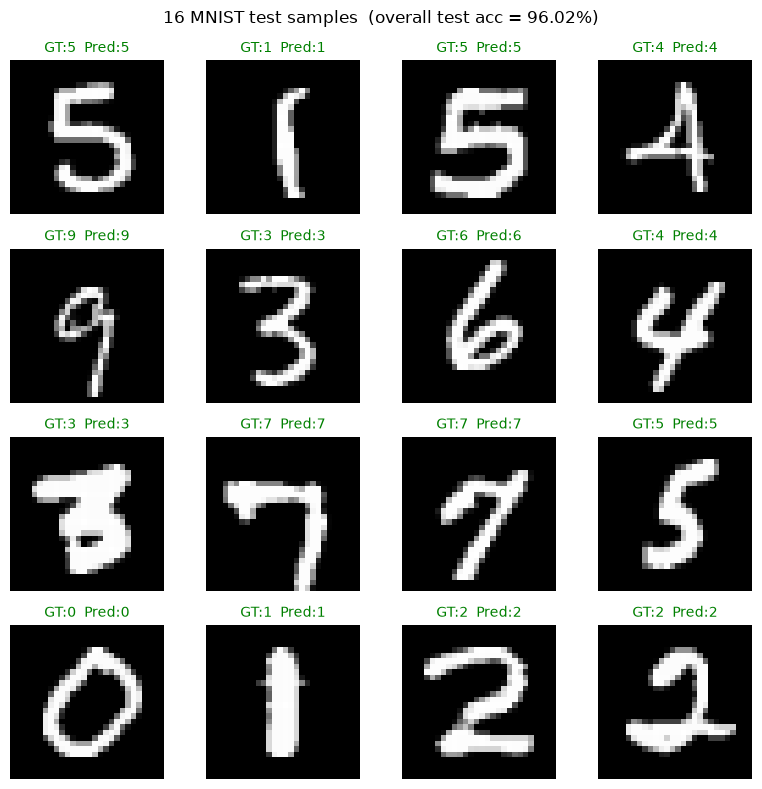

Sample (ground-truth, predicted) pairs:
[(5, 5), (1, 1), (5, 5), (4, 4), (9, 9), (3, 3), (6, 6), (4, 4), (3, 3), (7, 7), (7, 7), (5, 5), (0, 0), (1, 1), (2, 2), (2, 2)]
Correct in this sample: 16/16


In [7]:
# ============================================================
# Display 16 test images (4x4 grid) with ground-truth vs predicted
# ============================================================
# Deterministically pick 16 indices so the figure is reproducible.
rng = np.random.default_rng(SEED)
idx = rng.choice(len(X_test), size=16, replace=False)
idx = np.sort(idx)

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, i in zip(axes.ravel(), idx):
    img = X_test[i].squeeze(0).cpu().numpy()       # (28, 28)
    gt  = int(y_test[i]); pr = int(preds[i])
    color = 'green' if gt == pr else 'red'
    ax.imshow(img, cmap='gray')
    ax.set_title(f'GT:{gt}  Pred:{pr}', fontsize=10, color=color)
    ax.axis('off')
fig.suptitle(f'16 MNIST test samples  (overall test acc = {test_acc*100:.2f}%)',
             fontsize=12)
plt.tight_layout()
plt.show()

# Also print the 16 pairs as text for the log.
pairs = [(int(y_test[i]), int(preds[i])) for i in idx]
print('Sample (ground-truth, predicted) pairs:')
print(pairs)
print(f'Correct in this sample: {sum(g==p for g,p in pairs)}/16')


In [8]:
# ============================================================
# Final summary
# ============================================================
print('=' * 50)
print('AI231 ME1 — 3-Layer CNN (tensor ops only) — SUMMARY')
print('=' * 50)
print('Architecture : Conv1(1->16,3x3)+ReLU+MP2 -> Conv2(16->32,3x3)+ReLU+MP2')
print('               -> Conv3(32->64,3x3)+ReLU+GAP -> FC(64->10)')
print('Param counts :')
for name, p in model.named_parameters():
    print(f'   {name:6s} {tuple(p.shape)}  ({p.numel():,})')
print(f'Total params : {n_params:,}')
print('Training     : 5 epochs, batch 128, Adam lr=1e-3, CrossEntropy')
print('Per-epoch log:')
for e, l, a in history:
    print(f'   Epoch {e}: loss={l:.4f}  acc={a:.4f}')
print(f'TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)')
print('=' * 50)


AI231 ME1 — 3-Layer CNN (tensor ops only) — SUMMARY
Architecture : Conv1(1->16,3x3)+ReLU+MP2 -> Conv2(16->32,3x3)+ReLU+MP2
               -> Conv3(32->64,3x3)+ReLU+GAP -> FC(64->10)
Param counts :
   w1     (16, 1, 3, 3)  (144)
   b1     (16,)  (16)
   w2     (32, 16, 3, 3)  (4,608)
   b2     (32,)  (32)
   w3     (64, 32, 3, 3)  (18,432)
   b3     (64,)  (64)
   fw     (10, 64)  (640)
   fb     (10,)  (10)
Total params : 23,946
Training     : 5 epochs, batch 128, Adam lr=1e-3, CrossEntropy
Per-epoch log:
   Epoch 1: loss=0.9734  acc=0.6945
   Epoch 2: loss=0.3125  acc=0.9085
   Epoch 3: loss=0.2306  acc=0.9309
   Epoch 4: loss=0.1933  acc=0.9427
   Epoch 5: loss=0.1669  acc=0.9497
TEST ACCURACY: 0.9602 (96.02%)
